<a href="https://colab.research.google.com/github/rezamarzban/correct_segments/blob/main/check_convergence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!apt install nec2c

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  nec2c
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 122 kB of archives.
After this operation, 319 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 nec2c amd64 1.3-4 [122 kB]
Fetched 122 kB in 1s (162 kB/s)
Selecting previously unselected package nec2c.
(Reading database ... 121658 files and directories currently installed.)
Preparing to unpack .../archives/nec2c_1.3-4_amd64.deb ...
Unpacking nec2c (1.3-4) ...
Setting up nec2c (1.3-4) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
# Do simulations (for given specific parameters) within segments number=5 to 75 at each simulation to checking results convergence and choose best segments number
# RP card has no effect on critical results, So set it's values to minimum.
%%writefile do_simulations.sh
echo "" > realimpedances.tmp && rm realimpedances.tmp
echo "" > imageimpedances.tmp && rm imageimpedances.tmp

for segments in {5..75}
do
   echo "GW 0 $segments 0. 0. 1.5 0. 0. 3 .005" > do.nec
   echo "GE -1" >> do.nec
   echo "GN 2 0 0 0 3 0.0001" >> do.nec
   echo "EK -1" >> do.nec
   echo "FR 0 1 0 0 100." >> do.nec
   echo "EX 0 0 1 0 1." >> do.nec
   echo "LD 5 0 0 0 1390000 0" >> do.nec
   echo "RP 0 1 0 0000 0 0 90 0" >> do.nec
   echo "EN" >> do.nec
   nec2c -i do.nec
   grep -A 3 "ANTENNA INPUT PARAMETERS" do.out | tail -1 | awk '{print $7}' >> realimpedances.tmp
   grep -A 3 "ANTENNA INPUT PARAMETERS" do.out | tail -1 | awk '{print $8}' >> imageimpedances.tmp
done

Writing do_simulations.sh


In [3]:

!chmod -c 755 do_simulations.sh

mode of 'do_simulations.sh' changed from 0644 (rw-r--r--) to 0755 (rwxr-xr-x)


In [4]:

!./do_simulations.sh

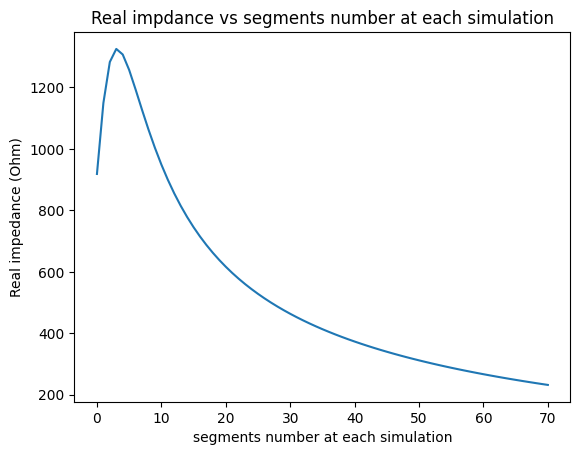

In [5]:

import matplotlib.pyplot as plt

# Read data from a text file
with open('realimpedances.tmp', 'r') as file:
    data = [float(line.strip()) for line in file]

# Create a basic plot
plt.plot(data)

# Add labels and title
plt.xlabel('segments number at each simulation')
plt.ylabel('Real impedance (Ohm)')
plt.title('Real impdance vs segments number at each simulation')

# Show the plot
plt.show()

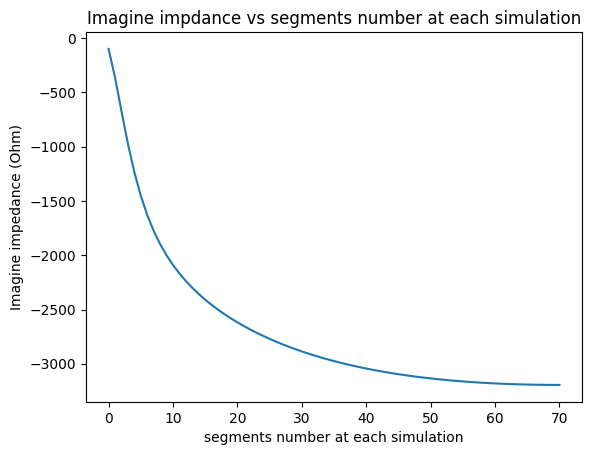

In [6]:

import matplotlib.pyplot as plt

# Read data from a text file
with open('imageimpedances.tmp', 'r') as file:
    data = [float(line.strip()) for line in file]

# Create a basic plot
plt.plot(data)

# Add labels and title
plt.xlabel('segments number at each simulation')
plt.ylabel('Imagine impedance (Ohm)')
plt.title('Imagine impdance vs segments number at each simulation')

# Show the plot
plt.show()

In [7]:
!echo "According to recommendations and convergence at above plots the 11 segments number should be correct for given parameters simulation, So:"

According to recommendations and convergence at above plots the 11 segments number should be correct for given parameters simulation, So:


In [8]:
# Here set RP card params to max for full simulation
%%writefile simulation.nec
GW 0 11 0. 0. 1.5 0. 0. 3 .005
GE -1
GN 2 0 0 0 3 0.0001
EK -1
FR 0 1 0 0 100.
EX 0 0 1 0 1.
LD 5 0 0 0 1390000 0
RP 0 90 90 0000 0 0 1 1
EN

Writing simulation.nec


In [9]:

!nec2c -i simulation.nec
!grep -A 4 "ANTENNA INPUT PARAMETERS" simulation.out
!grep -A 6 "POWER BUDGET" simulation.out

                        --------- ANTENNA INPUT PARAMETERS ---------
  TAG   SEG       VOLTAGE (VOLTS)         CURRENT (AMPS)         IMPEDANCE (OHMS)        ADMITTANCE (MHOS)     POWER
  No:   No:     REAL      IMAGINARY     REAL      IMAGINARY     REAL      IMAGINARY    REAL       IMAGINARY   (WATTS)
    0     1  1.0000E+00  0.0000E+00  2.9265E-04  3.9945E-04  1.1935E+03 -1.6291E+03  2.9265E-04  3.9945E-04  1.4632E-04

                               ---------- POWER BUDGET ---------
                               INPUT POWER   =  1.4632E-04 Watts
                               RADIATED POWER=  1.4550E-04 Watts
                               STRUCTURE LOSS=  8.2444E-07 Watts
                               NETWORK LOSS  =  0.0000E+00 Watts
                               EFFICIENCY    =   99.44 Percent



In [11]:
!echo "According to radiation resistance graph for vertical antenna fed at the base, The radiation resistance is about 1000 Ohm at 0.5 wavelength which shows simulation result (real impedance=Radiation resistance + Wire resistance=1193 Ohm) is correct"

According to radiation resistance graph for vertical antenna fed at the base, The radiation resistance is about 1000 Ohm at 0.5 wavelength which shows simulation result (real impedance=Radiation resistance + Wire resistance=1193 Ohm) is correct


In [12]:

!segments_n=11 && grep -A $((4 + $segments_n - 1)) "CURRENTS AND LOCATION" simulation.out | tail -$(($segments_n - 1)) | awk '{print $7}' > real_currents.txt

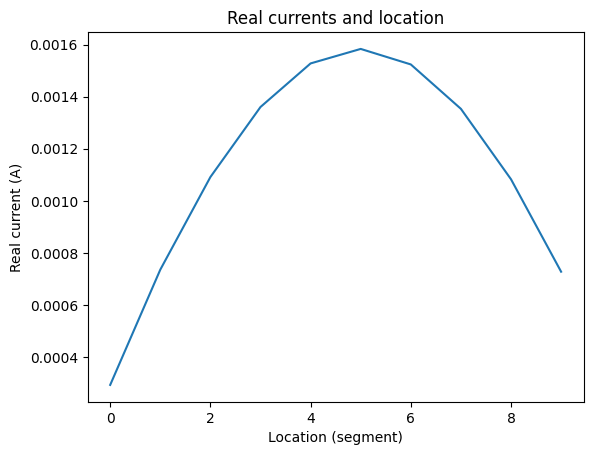

In [13]:

import matplotlib.pyplot as plt

# Read data from a text file
with open('real_currents.txt', 'r') as file:
    data = [float(line.strip()) for line in file]

# Create a basic plot
plt.plot(data)

# Add labels and title
plt.xlabel('Location (segment)')
plt.ylabel('Real current (A)')
plt.title('Real currents and location')

# Show the plot
plt.show()